<a href="https://colab.research.google.com/github/VatsalP04/6CCSAACV_coursework/blob/exercises/acv_week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy
!pip install opencv-python
!pip install matplotlib
!pip install cupy-cuda12x

import os
from google.colab import drive

def mount_google_drive(drive_path = "/content/drive"):
  """Check if Google Drive is mounted in Colab. Mount it if not."""
  if os.path.exists(drive_path):
    print("Google Drive is already mounted.")
  else:
    print("Mounting Google Drive...")
    drive.mount(drive_path)
    if os.path.exists(drive_path):
      print("Google Drive mounted successfully.")
    else:
      print("Failed to mount Google Drive. Please try again.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.8 MB/s eta 0:00:00


In [3]:
mount_google_drive()

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.


In [6]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32.zip'
extract_to = '/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets'

# Make sure the extraction folder exists
os.makedirs(extract_to, exist_ok=True)

# Extract the zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

In [25]:
mount_google_drive()

def list_all_images(file_path):
    """List all image filenames in a directory."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Directory not found: {file_path}")

    images = []
    for filename in os.listdir(file_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            images.append(filename)

    if len(images) == 0:
        print("No images found in the directory.")

    return images

Google Drive is already mounted.


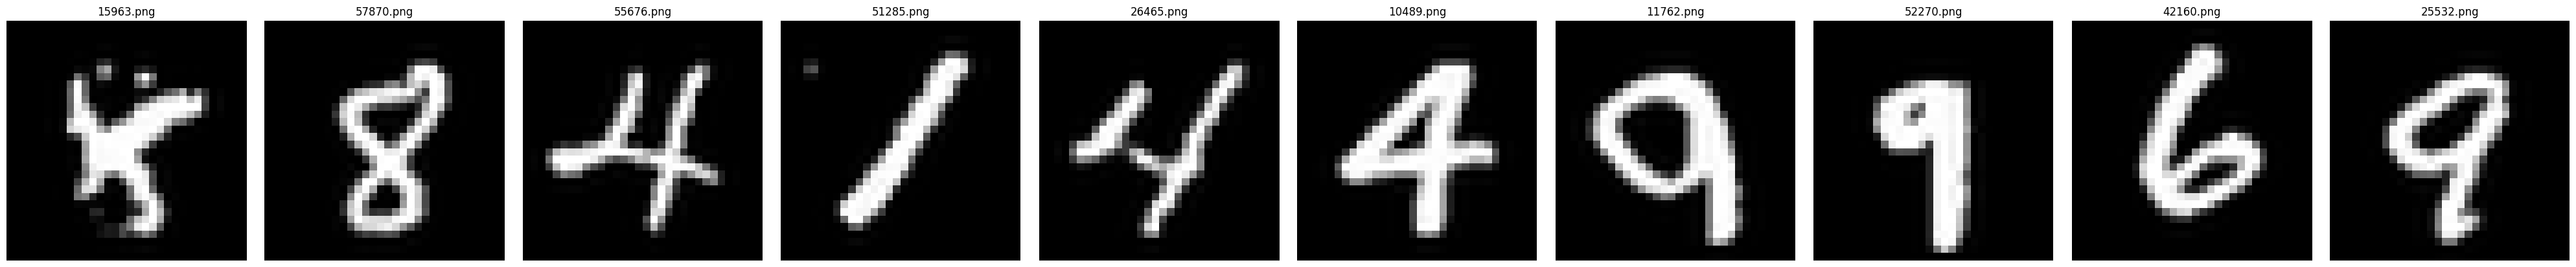

In [19]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import random

def display_N_images(N, file_path):
  # Use random.sample instead of random.choice to select N unique images
  random_imgs = random.sample(list_all_images(file_path),k=N)

  # Create subplot
  fig, axes = plt.subplots(1, N, figsize=(4*N, 4))

  # If N == 1, axes is not a list
  if N == 1:
      axes = [axes]

  for ax, filename in zip(axes, random_imgs):
      path = os.path.join(file_path, filename)

      # Load image using OpenCV
      img = cv.imread(path)
      assert img is not None, f"Could not read {filename}"

      # Convert BGR (OpenCV) → RGB (Matplotlib)
      img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

      # Display image
      ax.imshow(img)
      ax.set_title(filename)
      ax.axis("off")   # hide ticks and labels

  plt.tight_layout()
  plt.show()

display_N_images(10, "/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32")

In [26]:
import random
import json
import os # Import os module for directory operations

def cross_val_imgs(SEED, K, file_path, output_jsons):
    os.makedirs(output_jsons, exist_ok=True)

    all_images = list_all_images(file_path)
    if len(all_images) < K:
        raise ValueError(f"Need at least {K} images, found {len(all_images)}")

    random.seed(SEED)
    random.shuffle(all_images)

    n = len(all_images)
    fold_size = n // K

    for i in range(K):
        val_start = i * fold_size
        val_end = (i + 1) * fold_size if i < K - 1 else n

        val_files = all_images[val_start:val_end]
        train_files = all_images[:val_start] + all_images[val_end:]

        fold_data = {"train": train_files, "val": val_files}

        fold_path = os.path.join(output_jsons, f"fold_{i+1}.json")
        with open(fold_path, "w") as f:
            json.dump(fold_data, f, indent=4)

        print("Saved:", fold_path)

cross_val_imgs(SEED = 2025, K = 5, file_path = "/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32", output_jsons= "/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val")
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val"))


Saved: /content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val/fold_1.json
Saved: /content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val/fold_2.json
Saved: /content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val/fold_3.json
Saved: /content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val/fold_4.json
Saved: /content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val/fold_5.json
['fold_1.json', 'fold_2.json', 'fold_3.json', 'fold_4.json', 'fold_5.json']


['32143.png', '12293.png', '24721.png', '9096.png', '43962.png', '34532.png', '57917.png', '11942.png', '20547.png', '38308.png', '10484.png', '27228.png', '48837.png', '30754.png', '21881.png', '5874.png', '26136.png', '29205.png', '36325.png', '39016.png']


Google Drive is already mounted.
Batch images shape: (8, 1, 32, 32)
Batch labels shape: (8, 16)
Training image 0:


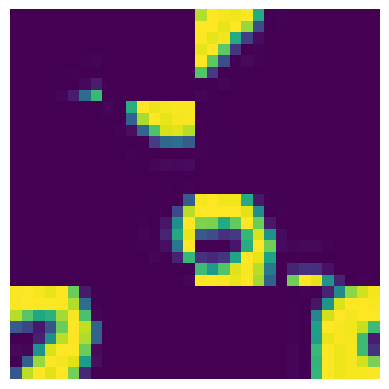

Original image 0:


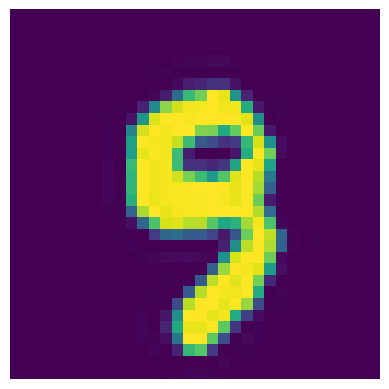

Training image 1:


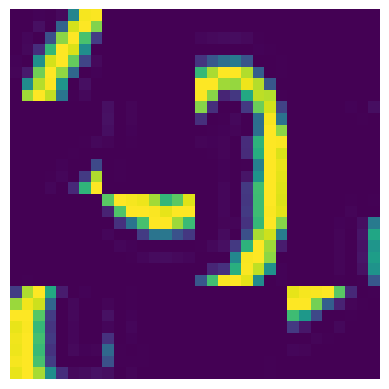

Original image 1:


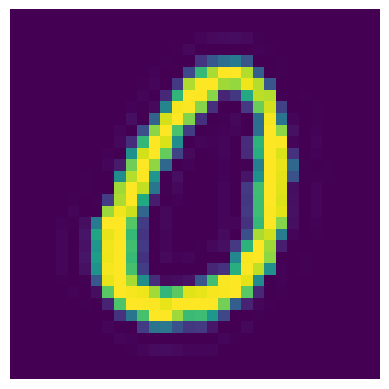

Training image 2:


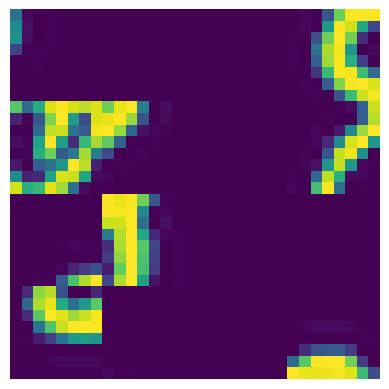

Original image 2:


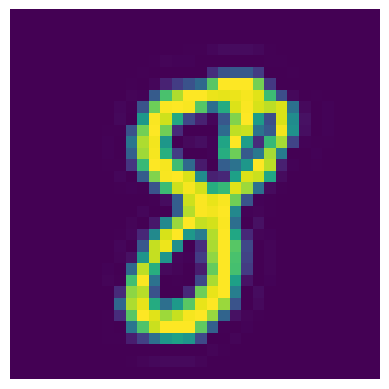

Training image 3:


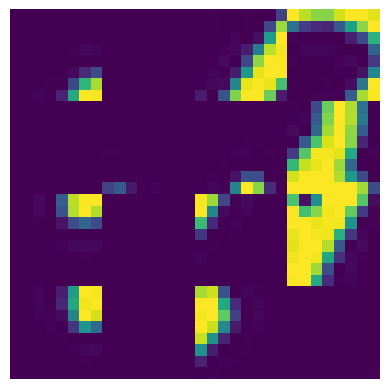

Original image 3:


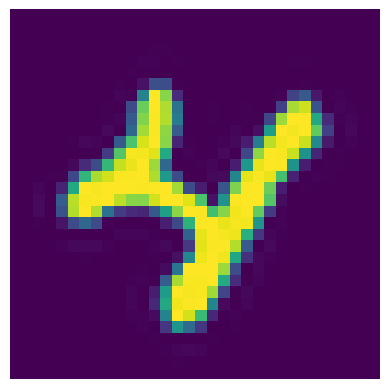

Training image 4:


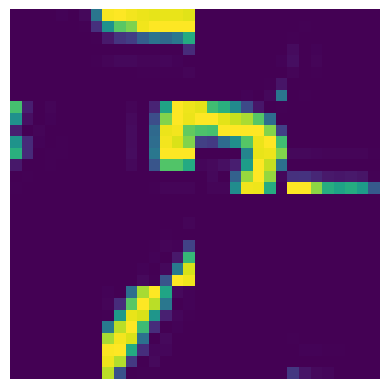

Original image 4:


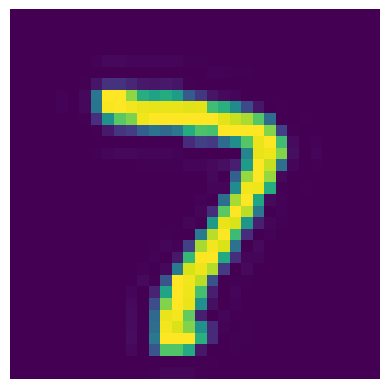

Training image 5:


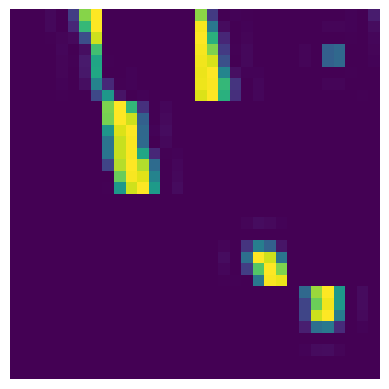

Original image 5:


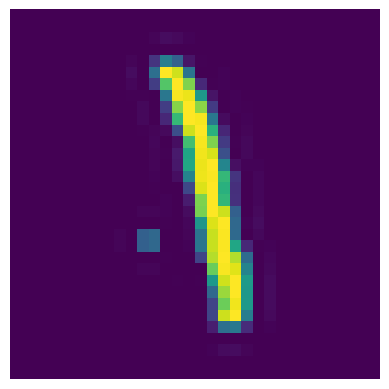

Training image 6:


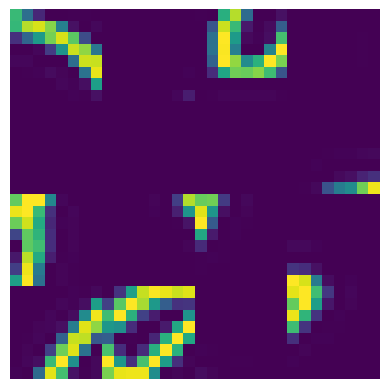

Original image 6:


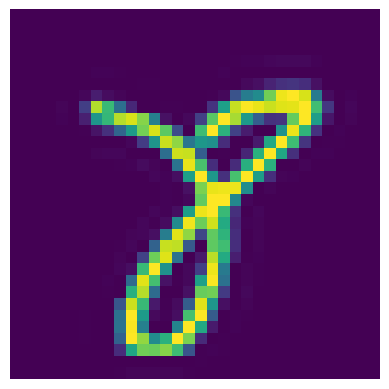

Training image 7:


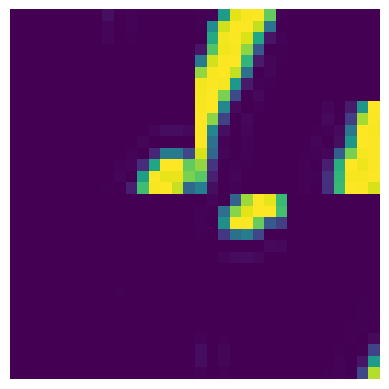

Original image 7:


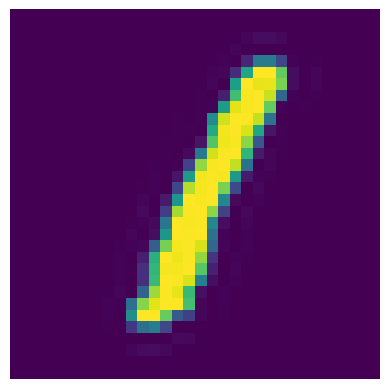

In [33]:
import random
import json
import os
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import random
from google.colab import drive
from typing import Tuple, List # Import Tuple and List for type hinting

class PatchShuffleDataLoader:
  def __init__(self, json_file: str, dataset_dir: str, batch_size: int = 8, image_size: Tuple[int, int] = (32, 32), num_patches: int = 4,shuffle: bool = True):
      """
      DataLoader with patch shuffling.
      Labels are permutation vectors of length num_patches^2.
      Args:
        json_file (str): Path to JSON file (contains "train" and "val" lists).
        dataset_dir (str): Root dataset directory containing the images.
        batch_size (int): Number of samples per batch (default=8).
        image_size (Tuple[int,int]): Resize images to this size (W, H).
        Default is (32, 32).
        num_patches (int): Number of patches along one dimension (default=4).
        shuffle (bool): Shuffle dataset each epoch if True (default=True).
      """
      self.dataset_dir = dataset_dir
      self.batch_size = batch_size
      self.image_size = image_size
      self.num_patches = num_patches
      self.shuffle = shuffle

      # Load train and validation files from the JSON file
      with open(json_file, 'r') as f:
          data = json.load(f)
      self.train_files = data['train']
      self.val_files = data['val']

  def _shuffle_patches(self, image: np.ndarray, indices: np.ndarray = None) -> Tuple[np.ndarray, np.ndarray]:
      """
      Divide image into patches, shuffle, reconstruct and return permuted image and permutation labels.
      Parameters:
          image (np.ndarray): Input image of shape (H, W, C)
          indices (np.ndarray, optional): Predefined permutation of patch indices.
                                          If None, a random shuffle is used.
      Returns:
          Tuple[np.ndarray, np.ndarray]: Shuffled image and the permutation indices
      """
      # (a) Calculate dimensions
      H, W = image.shape[0], image.shape[1]
      N = self.num_patches  # patches per dimension
      ph, pw = H // N, W // N

      # Safety checks: ensure exact tiling
      if H % N != 0 or W % N != 0:
          raise ValueError(
              f"Image size ({H}, {W}) not divisible by num_patches={N}. "
              "Choose a different num_patches or resize/crop the image."
          )

      # Store patch size if you want it as a class attribute
      self.patch_size = (ph, pw)

      # (b) Extract patches (flatten into 1D list in row-major order)
      patches = []
      for i in range(N):          # rows
          for j in range(N):      # cols
              patch = image[i*ph:(i+1)*ph, j*pw:(j+1)*pw, :]
              patches.append(patch)
      patches = np.array(patches)  # shape: (N^2, ph, pw, C)

      # (c) Handle indices (permutation)
      num_total = N * N
      if indices is None:
          indices = np.random.permutation(num_total)
      else:
          indices = np.asarray(indices)
          if indices.shape != (num_total,):
              raise ValueError(f"indices must have shape ({num_total},), got {indices.shape}")
          if set(indices.tolist()) != set(range(num_total)):
              raise ValueError("indices must be a permutation of 0..N^2-1 (no repeats, none missing)")

      # (d) Reconstruct shuffled image + build label mapping
      shuffled_image = np.empty_like(image)
      label = np.empty(num_total, dtype=np.int64)

      for new_pos, original_id in enumerate(indices):
          # new_pos -> (i, j) in the output grid
          out_i = new_pos // N
          out_j = new_pos % N

          # place the chosen original patch into this output location
          shuffled_image[out_i*ph:(out_i+1)*ph, out_j*pw:(out_j+1)*pw, :] = patches[original_id]

          # label maps original patch id -> where it ended up
          label[original_id] = new_pos

      # (e) Return
      return shuffled_image, label



  def _load_image(self, filepath: str)-> Tuple[np.ndarray, np.ndarray]:
      """
      Load and preprocess a single image with patch shuffling
      (CHW + permutation labels).

      -> Tuple[np.ndarray, np.ndarray]:
      """
       # (a) File I/O: construct full path and load image
      full_path = os.path.join(self.dataset_dir, filepath)
      image = cv.imread(full_path)

      if image is None:
          raise ValueError(f"Failed to load image: {full_path}")

      # (b) Color conversion: BGR -> grayscale
      image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

      # (c) Resize to target image size
      image = cv.resize(image, self.image_size)

      # (d) Dimension check: ensure (H, W, 1)
      if image.ndim == 2:
          image = image[:, :, np.newaxis]

      # (e) Patch shuffle: get shuffled image and permutation labels
      image, labels = self._shuffle_patches(image)

      # (f) Normalisation: float32 and scale to [0, 1]
      image = image.astype(np.float32) / 255.0

      # (g) Transpose: Channel-Last (H, W, C) -> Channel-First (C, H, W)
      image = np.transpose(image, (2, 0, 1))

      # (h) Return processed image and labels
      return image, labels



  def _get_batches(self, file_list: List[str]):
      """ Yield mini-batches of data and patch permutation labels.
      Args:
          file_list (List[str]): List of image filenames to process.
      Yields:
          Tuple[np.ndarray, np.ndarray]:
            - Batch of images: Shape (B, C, H, W)
            - Batch of labels: Shape (B, N^2) where N is num_patches
      """
      # (a) Shuffle
      files = list(file_list)  # avoid modifying the original list
      if getattr(self, "shuffle", False):
          random.shuffle(files)

      # (b) Batch loop
      for start in range(0, len(files), self.batch_size):
          batch_files = files[start:start + self.batch_size]

          X, Y = [], []

          # Image processing loop
          for fname in batch_files:
              img, label = self._load_image(fname)  # img: (C,H,W), label: (N^2,)
              X.append(img)
              Y.append(label)

          # Convert to NumPy
          X = np.stack(X, axis=0)  # (B,C,H,W)
          Y = np.stack(Y, axis=0)  # (B,N^2)

          # Yield batch
          yield X, Y

  def train_batches(self):
    return self._get_batches(self.train_files)

  def val_batches(self):
    return self._get_batches(self.val_files)


  def display_training_image(self, image: np.ndarray):
    # CHW -> HWC
    new_im = np.transpose(image, (1, 2, 0))
    # De-normalize back to [0, 255]
    new_im = np.clip(new_im * 255.0, 0, 255).astype(np.uint8)
    # Show image
    plt.imshow(new_im)
    plt.axis("off")
    plt.show()

  def display_reconstructed_training_image(self, image: np.ndarray,label: np.ndarray):
    # CHW -> HWC
    new_im = np.transpose(image, (1, 2, 0))
    # De-normalize back to [0, 255]
    new_im = np.clip(new_im * 255.0, 0, 255).astype(np.uint8)
    # Bring the patches back to their original position
    new_im, _ = self._shuffle_patches(new_im, label)
    # Show image
    plt.imshow(new_im)
    plt.axis("off")
    plt.show()


if __name__ == "__main__":
  # Mount Google Drive (if not mounted yet)
  mount_google_drive()

  # Create dataloader
  dataset_dir = "/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32"
  json_file = "/content/drive/MyDrive/Colab Notebooks/acv_exercises/datasets/acv_train_32x32_cross_val/fold_1.json"
  loader = PatchShuffleDataLoader(json_file, dataset_dir, batch_size=8)

  # Loop over training batches (just one iteration for demo)
  for X_batch, Y_batch in loader.train_batches():
    print("Batch images shape:", X_batch.shape) # (8, 1, 32, 32)
    print("Batch labels shape:", Y_batch.shape) # (8, 16)
    for i in range(loader.batch_size):
      print(f"Training image {i}:")
      loader.display_training_image(X_batch[i])
      print(f"Original image {i}:")
      loader.display_reconstructed_training_image(X_batch[i], Y_batch[i])
    break